In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

RESULTS_DIR = './results'


In [2]:
RESULT_FILES = [
    ('baseline_fp32.json',        'Baseline FP32\n(beam=5)'),
    ('baseline_fp32_greedy.json', 'Baseline FP32\n(greedy)'),
    ('onnx_fp32.json',            'ONNX FP32\n(greedy+KV)'),
    ('pytorch_int8.json',         'PyTorch INT8\n(torchao)'),
    ('onnx_int8.json',            'ONNX INT8\n(decoder-only)'),
]

records = []
labels  = []
for fname, label in RESULT_FILES:
    fpath = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(fpath):
        with open(fpath, encoding='utf-8') as f:
            data = json.load(f)
        if 'bleu4' in data and 'rougeL' in data:
            records.append(data)
            labels.append(label)
            print(f"  Loaded: {fname}")
        else:
            print(f"  SKIP (no metrics): {fname}")
    else:
        print(f"  NOT FOUND: {fname}")

print(f"\nTotal: {len(records)} variants loaded")


  Loaded: baseline_fp32.json
  Loaded: baseline_fp32_greedy.json
  Loaded: onnx_fp32.json
  Loaded: pytorch_int8.json
  NOT FOUND: onnx_int8.json

Total: 4 variants loaded


In [3]:
DISPLAY_COLS = [
    'name', 'backend', 'precision',
    'generation_strategy', 'quantization_scope',
    'bleu4', 'rougeL', 'meteor',
    'avg_latency_seconds_per_batch',
    'throughput_images_per_second',
    'num_images',
]

df = pd.DataFrame(records)
existing = [c for c in DISPLAY_COLS if c in df.columns]
df_display = df[existing].copy()

if 'baseline_fp32' in df_display.get('name', pd.Series()).values:
    ref_lat = df_display.loc[df_display['name']=='baseline_fp32',
                              'avg_latency_seconds_per_batch'].values[0]
    df_display['speedup_vs_beam_fp32'] = (ref_lat /
        df_display['avg_latency_seconds_per_batch']).round(2)

for col in ['bleu4','rougeL','meteor','throughput_images_per_second']:
    if col in df_display.columns:
        df_display[col] = df_display[col].round(2)
if 'avg_latency_seconds_per_batch' in df_display.columns:
    df_display['avg_latency_seconds_per_batch'] = df_display['avg_latency_seconds_per_batch'].round(2)

df_display


,name,backend,precision,generation_strategy,quantization_scope,bleu4,rougeL,meteor,avg_latency_seconds_per_batch,throughput_images_per_second,num_images,speedup_vs_beam_fp32
0,baseline_fp32,pytorch,fp32,NaN,NaN,24.50,50.55,35.88,28.36,0.56,200,1.00
1,baseline_fp32_greedy,pytorch,fp32,greedy,NaN,22.83,49.85,35.34,17.80,0.90,200,1.59
2,onnx_fp32,onnx,fp32,greedy+kvcache,NaN,22.83,49.85,35.34,14.01,1.14,200,2.02
3,pytorch_int8,pytorch,int8,greedy,decoder_only,15.55,46.21,34.18,26.05,0.61,200,1.09


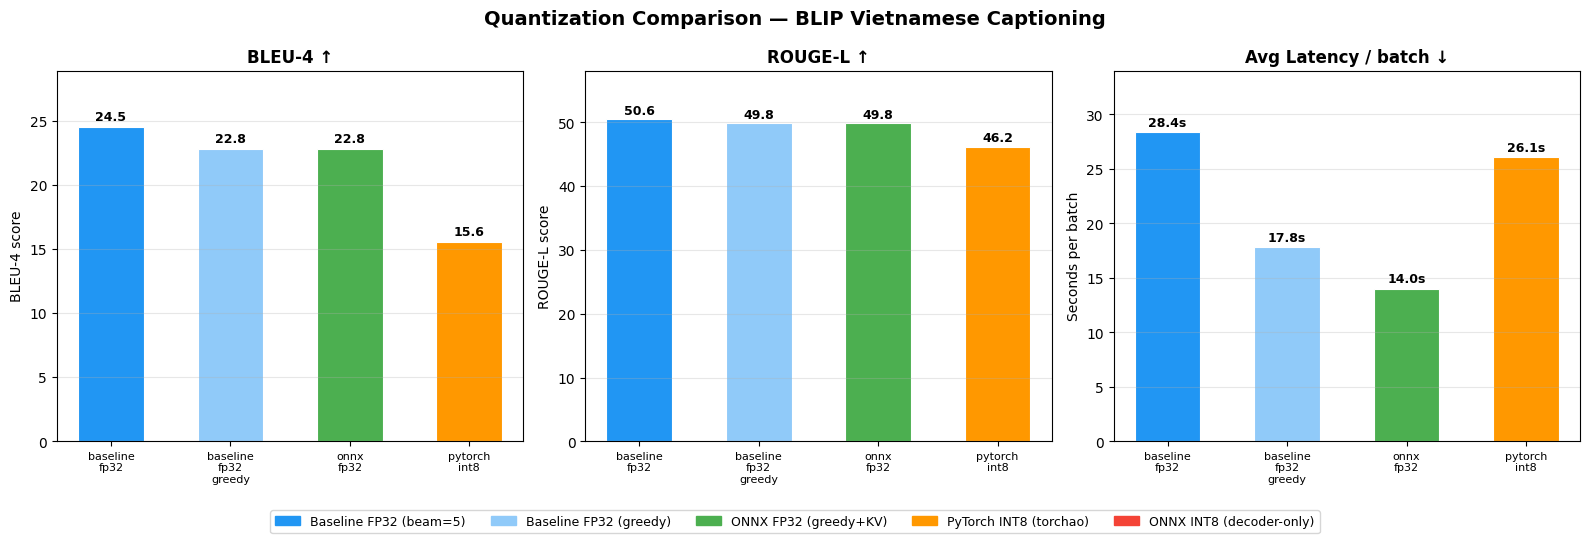

Chart saved: results/comparison_chart.png


In [4]:
COLORS = {
    'baseline_fp32':        '#2196F3',
    'baseline_fp32_greedy': '#90CAF9',
    'onnx_fp32':            '#4CAF50',
    'pytorch_int8':         '#FF9800',
    'onnx_int8':            '#F44336',
}

names_in_df = df['name'].tolist()
bar_labels  = []
bar_colors  = []
for name in names_in_df:
    bar_colors.append(COLORS.get(name, '#9E9E9E'))
    bar_labels.append(name.replace('_', '\n'))

x = np.arange(len(df))
w = 0.55

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Quantization Comparison — BLIP Vietnamese Captioning', fontsize=14, fontweight='bold')

ax = axes[0]
bars = ax.bar(x, df['bleu4'], width=w, color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_title('BLEU-4 ↑', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(bar_labels, fontsize=8)
ax.set_ylim(0, max(df['bleu4']) * 1.18)
for bar, val in zip(bars, df['bleu4']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('BLEU-4 score')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
bars = ax.bar(x, df['rougeL'], width=w, color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_title('ROUGE-L ↑', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(bar_labels, fontsize=8)
ax.set_ylim(0, max(df['rougeL']) * 1.15)
for bar, val in zip(bars, df['rougeL']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('ROUGE-L score')
ax.grid(axis='y', alpha=0.3)

ax = axes[2]
bars = ax.bar(x, df['avg_latency_seconds_per_batch'], width=w,
              color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_title('Avg Latency / batch ↓', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(bar_labels, fontsize=8)
ax.set_ylim(0, max(df['avg_latency_seconds_per_batch']) * 1.2)
for bar, val in zip(bars, df['avg_latency_seconds_per_batch']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Seconds per batch')
ax.grid(axis='y', alpha=0.3)

legend_patches = [
    mpatches.Patch(color='#2196F3', label='Baseline FP32 (beam=5)'),
    mpatches.Patch(color='#90CAF9', label='Baseline FP32 (greedy)'),
    mpatches.Patch(color='#4CAF50', label='ONNX FP32 (greedy+KV)'),
    mpatches.Patch(color='#FF9800', label='PyTorch INT8 (torchao)'),
    mpatches.Patch(color='#F44336', label='ONNX INT8 (decoder-only)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_chart.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: results/comparison_chart.png")


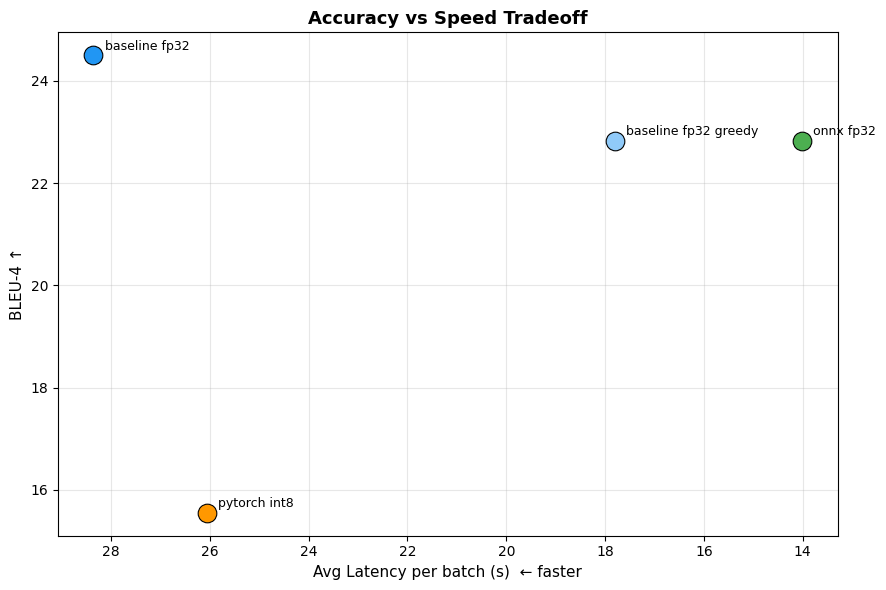

Scatter saved: results/tradeoff_scatter.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

for i, (name, rec) in enumerate(zip(names_in_df, records)):
    if 'bleu4' not in rec or 'avg_latency_seconds_per_batch' not in rec:
        continue
    ax.scatter(
        rec['avg_latency_seconds_per_batch'], rec['bleu4'],
        color=COLORS.get(name, '#9E9E9E'), s=180, zorder=5,
        edgecolors='black', linewidths=0.8,
    )
    ax.annotate(
        name.replace('_', ' '),
        (rec['avg_latency_seconds_per_batch'], rec['bleu4']),
        textcoords='offset points', xytext=(8, 4), fontsize=9,
    )

ax.set_xlabel('Avg Latency per batch (s)  ← faster', fontsize=11)
ax.set_ylabel('BLEU-4 ↑', fontsize=11)
ax.set_title('Accuracy vs Speed Tradeoff', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'tradeoff_scatter.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Scatter saved: results/tradeoff_scatter.png")


In [6]:
print("=" * 80)
print("QUANTIZATION BENCHMARK SUMMARY")
print("=" * 80)

summary_cols = ['name', 'precision', 'bleu4', 'rougeL', 'meteor',
                'avg_latency_seconds_per_batch', 'throughput_images_per_second']
existing = [c for c in summary_cols if c in df.columns]
df_summary = df[existing].copy()

if 'baseline_fp32_greedy' in df_summary['name'].values:
    ref_bleu = df_summary.loc[df_summary['name']=='baseline_fp32_greedy', 'bleu4'].values[0]
    ref_lat  = df_summary.loc[df_summary['name']=='baseline_fp32_greedy',
                               'avg_latency_seconds_per_batch'].values[0]
elif 'baseline_fp32' in df_summary['name'].values:
    ref_bleu = df_summary.loc[df_summary['name']=='baseline_fp32', 'bleu4'].values[0]
    ref_lat  = df_summary.loc[df_summary['name']=='baseline_fp32',
                               'avg_latency_seconds_per_batch'].values[0]
else:
    ref_bleu = ref_lat = None

if ref_bleu:
    df_summary['bleu4_drop'] = (df_summary['bleu4'] - ref_bleu).round(2)
if ref_lat:
    df_summary['speedup'] = (ref_lat / df_summary['avg_latency_seconds_per_batch']).round(2)

for col in ['bleu4','rougeL','meteor','avg_latency_seconds_per_batch',
            'throughput_images_per_second']:
    if col in df_summary.columns:
        df_summary[col] = df_summary[col].round(2)

print(df_summary.to_string(index=False))
print("\n(bleu4_drop < 0 = mất điểm so với FP32 greedy baseline)")
print("(speedup > 1 = nhanh hơn FP32 greedy baseline)")


QUANTIZATION BENCHMARK SUMMARY
                name precision  bleu4  rougeL  meteor  avg_latency_seconds_per_batch  throughput_images_per_second  bleu4_drop  speedup
       baseline_fp32      fp32  24.50   50.55   35.88                          28.36                          0.56        1.68     0.63
baseline_fp32_greedy      fp32  22.83   49.85   35.34                          17.80                          0.90        0.00     1.00
           onnx_fp32      fp32  22.83   49.85   35.34                          14.01                          1.14        0.00     1.27
        pytorch_int8      int8  15.55   46.21   34.18                          26.05                          0.61       -7.27     0.68

(bleu4_drop < 0 = mất điểm so với FP32 greedy baseline)
(speedup > 1 = nhanh hơn FP32 greedy baseline)
